In [1]:
import sys
from pyprojroot import here
sys.path.append(str(here()))

In [90]:
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.stats import skew, kurtosis
from sklearn.model_selection import train_test_split
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import classification_report
from src.utils.db_connect import get_db_connection


In [3]:
con = get_db_connection(read_only=True)

run_ids_query = f"""
SELECT run_id 
FROM SIMULATION_STEPS
GROUP BY run_id
HAVING COUNT(step_idx) = 10000
ORDER BY random()
LIMIT {100};
"""

single_run_query = """
SELECT 
    step_idx,
    bead_positions,
    state,
    target_theta
FROM SIMULATION_STEPS
WHERE run_id = ?
ORDER BY step_idx;
"""

random_runs = con.execute(run_ids_query).df()["run_id"].tolist()
print(f"Successfully selected {len(random_runs)} random run IDs to analyze!")

Successfully selected 100 random run IDs to analyze!


In [4]:
selected_run_id = random_runs[0]
df = con.execute(single_run_query, [selected_run_id]).df()

In [69]:
short_window = 10
long_window = 50

# 1. Pure Instantaneous Physics (No leaks, sharp single-frame triggers)
df['velocity'] = df['bead_positions'].diff().bfill()
df['acceleration'] = df['velocity'].diff().bfill()
df['abs_acceleration'] = df['acceleration'].abs()
df['velocity_smooth'] = df['velocity'].rolling(window=5, min_periods=1).mean()
df['acceleration_smooth'] = df['acceleration'].rolling(window=5, min_periods=1).mean()

# 2. Strict Historical Windows
df['rolling_mean_short'] = df['bead_positions'].rolling(window=short_window, min_periods=1).mean()
df['rolling_mean_long'] = df['bead_positions'].rolling(window=long_window, min_periods=1).mean()
df['total_variation'] = df['velocity'].abs().rolling(window=short_window, min_periods=1).sum()

df['rolling_std_short'] = df['bead_positions'].rolling(window=short_window, min_periods=1).std().bfill().ffill()
df['rolling_std_long'] = df['bead_positions'].rolling(window=long_window, min_periods=1).std().bfill().ffill()

df['rolling_skew'] = df['bead_positions'].rolling(window=long_window, min_periods=3).apply(lambda x: skew(x), raw=True).bfill().ffill()
df['rolling_kurtosis'] = df['bead_positions'].rolling(window=long_window, min_periods=3).apply(lambda x: kurtosis(x), raw=True).bfill().ffill()

df['lag_diff_5'] = df['bead_positions'].diff(periods=5).bfill()
df['lag_diff_10'] = df['bead_positions'].diff(periods=10).bfill()

df['is_change_point'] = (df['state'].diff() != 0).astype(int)
df.iloc[0, df.columns.get_loc('is_change_point')] = 0

feature_set = df.reset_index(drop=True)

In [6]:
feature_set.head()

,step_idx,bead_positions,state,target_theta,velocity,acceleration,abs_acceleration,rolling_mean_short,rolling_mean_long,total_variation,rolling_std_short,rolling_std_long,rolling_skew,rolling_kurtosis,lag_diff_5,lag_diff_10,is_change_point
0,0,0.148520,0,0.05236,-0.087941,0.000000,0.000000,0.148520,0.148520,0.087941,0.062184,0.062184,0.575718,-1.500000,-0.147206,-0.330402,0
1,1,0.060578,0,0.05236,-0.087941,0.000000,0.000000,0.104549,0.104549,0.175883,0.062184,0.062184,0.575718,-1.500000,-0.147206,-0.330402,0
2,2,0.468122,0,0.05236,0.407544,0.495486,0.495486,0.225740,0.225740,0.583427,0.214465,0.214465,0.575718,-1.500000,-0.147206,-0.330402,0
3,3,0.449033,0,0.05236,-0.019089,-0.426633,0.426633,0.281563,0.281563,0.602516,0.207674,0.207674,-0.084087,-1.877929,-0.147206,-0.330402,0
4,4,0.326016,0,0.05236,-0.123017,-0.103928,0.103928,0.290454,0.290454,0.725533,0.180946,0.180946,-0.253136,-1.592421,-0.147206,-0.330402,0


In [7]:
feature_set.describe()

,step_idx,bead_positions,state,target_theta,velocity,acceleration,abs_acceleration,rolling_mean_short,rolling_mean_long,total_variation,rolling_std_short,rolling_std_long,rolling_skew,rolling_kurtosis,lag_diff_5,lag_diff_10,is_change_point
count,10000.00000,10000.000000,10000.00000,10000.000000,10000.000000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4999.50000,7.158259,2.53700,7.148406,0.001121,-7.782675e-07,0.175045,7.153119,7.130200,1.190311,0.164851,0.247549,0.027657,-0.479027,0.005603,0.011178,0.002400
std,2886.89568,2.315498,0.77181,2.297683,0.149537,2.199494e-01,0.133169,2.312303,2.317528,0.288893,0.059196,0.072688,0.404696,0.563822,0.285072,0.348618,0.048933
min,0.00000,-0.297057,0.00000,0.052360,-0.544481,-8.505287e-01,0.000000,-0.159124,-0.013002,0.087941,0.040636,0.062184,-1.575632,-1.877929,-1.186408,-1.166995,0.000000
25%,2499.75000,5.856197,2.00000,6.213372,-0.098517,-1.485281e-01,0.070251,5.885121,5.951242,0.988117,0.122616,0.199975,-0.234456,-0.879368,-0.190075,-0.229060,0.000000
50%,4999.50000,7.995613,3.00000,8.307768,0.002195,1.398683e-03,0.148416,8.065142,8.158257,1.177262,0.154937,0.235280,0.023311,-0.589983,0.003855,0.006854,0.000000
75%,7499.25000,8.435853,3.00000,8.307768,0.102034,1.482032e-01,0.252836,8.409583,8.375672,1.380454,0.197430,0.278224,0.295253,-0.186367,0.197571,0.239060,0.000000
max,9999.00000,12.122141,3.00000,11.728613,0.603420,8.238587e-01,0.850529,11.974318,11.819880,2.299658,0.448525,0.791967,1.631256,3.896794,1.109257,1.387911,1.000000


In [8]:
feature_set.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   step_idx            10000 non-null  int32  
 1   bead_positions      10000 non-null  float64
 2   state               10000 non-null  int32  
 3   target_theta        10000 non-null  float64
 4   velocity            10000 non-null  float64
 5   acceleration        10000 non-null  float64
 6   abs_acceleration    10000 non-null  float64
 7   rolling_mean_short  10000 non-null  float64
 8   rolling_mean_long   10000 non-null  float64
 9   total_variation     10000 non-null  float64
 10  rolling_std_short   10000 non-null  float64
 11  rolling_std_long    10000 non-null  float64
 12  rolling_skew        10000 non-null  float64
 13  rolling_kurtosis    10000 non-null  float64
 14  lag_diff_5          10000 non-null  float64
 15  lag_diff_10         10000 non-null  float64
 16  is_change_point 

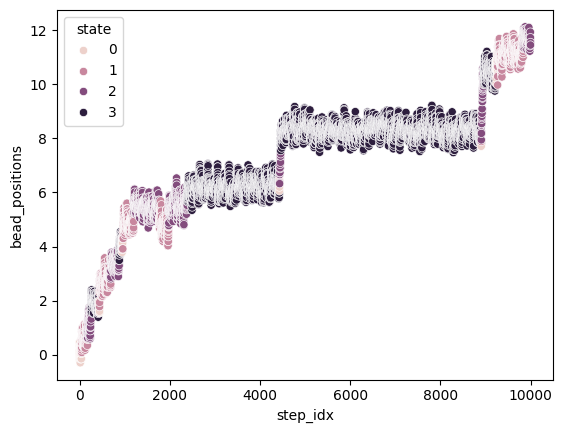

In [9]:
sns.scatterplot(x='step_idx', y='bead_positions', data=df, hue='state');

In [ ]:
X = df.drop(["state", "target_theta", "is_change_point"])
y = feature_set["is_change_point"]

In [71]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=101)

In [72]:
scaler = RobustScaler()
scaled_X_train_arr = scaler.fit_transform(X_train)
scaled_X_test_arr = scaler.transform(X_test)
scaled_X_train = pd.DataFrame(scaled_X_train_arr, columns=X_train.columns)
scaled_X_test = pd.DataFrame(scaled_X_test_arr, columns=X_test.columns)

In [87]:
clf = BalancedRandomForestClassifier(
    n_estimators=100, 
    sampling_strategy='not minority', 
    random_state=101,
    n_jobs=-1
)
clf.fit(scaled_X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [88]:
predictions = clf.predict(scaled_X_test)

In [94]:
print(
    classification_report(y_test, predictions, target_names=['Baseline Noise', 'Transition Step'])
)

                 precision    recall  f1-score   support

 Baseline Noise       1.00      0.55      0.71       999
Transition Step       0.00      0.00      0.00         1

       accuracy                           0.55      1000
      macro avg       0.50      0.27      0.35      1000
   weighted avg       1.00      0.55      0.71      1000



In [ ]:
# TODO next step, combine the entirety of the dataset into a df